# Does losing the NBA Finals make your city's stock market sad? 🏀📉
### A real "sports sentiment" effect — quietly killed by the fact that both teams trade the same stock market

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_the_loser's_city_dip%3F: Busted](https://img.shields.io/badge/Does_the_loser's_city_dip%3F-Busted-8b949e?style=flat-square)

There's a genuinely cool finding in finance: when a country gets knocked out of the soccer World Cup, its national stock market really does *dip* the next day — about half a percent, on average, out of pure collective disappointment (Edmans, García & Norli, 2007). No fundamentals, just mood. So here's the natural question: when a city's team **loses** the NBA Finals, does *that* city's market get gloomy too? And does the champion's city get a happy little pop?

We tested it on every NBA Finals from 2000 to 2025 — and the answer runs into a wall before the data even shows up.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo, the jackknife and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 26 Finals hardcoded from Basketball-Reference. No US city has a stock index, so each team's *home city* is stood in for by one real, tradable, deliberately-coarse hometown stock (the Lakers' LA → Disney, the Celtics' Boston → State Street, and so on). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nba_finals_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
    LOSER = INC[INC["role"] == "loser"]
    CHAMP = INC[INC["role"] == "champion"]
else:
    PRICES = EV = INC = LOSER = CHAMP = None
print("real cache present:", HAVE_REAL, "| Finals:", len(data.EVENTS),
      "| resolved role-events:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_finals': 26, 'n_possible': 52, 'n_included': 52, 'n_loser': 26, 'n_champ': 26, 'n_proxies': 17, 'fp': 'e68e0ed8bc79', 'l_day_mean': -0.149, 'l_day_t': -0.466, 'l_day_hit': 13, 'l_day_n': 26, 'l_wk_mean': 0.02, 'l_wk_t': 0.031, 'l_wk_hit': 15, 'l_wk_n': 26, 'c_day_mean': -0.354, 'c_day_t': -1.223, 'c_day_hit': 10, 'c_day_n': 26, 'c_wk_mean': -0.586, 'c_wk_t': -1.128, 'c_wk_hit': 12, 'c_wk_n': 26, 'comb_day_mean': -0.252, 'comb_day_t': -1.175, 'comb_day_n': 52, 'comb_wk_mean': -0.283, 'comb_wk_t': -0.678, 'spy_mean': 0.139, 'spy_t': 0.812, 'pl_l_day_p': 0.325, 'pl_l_day_mean': 0.015, 'pl_l_day_sd': 0.389, 'pl_c_day_p': 0.852, 'pl_l_wk_p': 0.491, 'pl_comb_day_p': 0.143, 'pl_c_capwk_p': 0.115, 'pl_c_capwk_mean': -0.062, 'pl_c_capwk_sd': 0.786, 'jk_lo': -1.571, 'jk_hi': -0.714, 'jk_n': 26, 'l_day_cap_g': -0.22, 'l_day_cap_n5': -0.32, 'l_day_cap_t5': -1.0, 'l_day_cap_n10': -0.42, 'l_day_cap_t10': -1.31, 'l_wk_cap_g': 0.372, 'l_wk_cap_n5': 0.272, 'l_wk_cap_t5': 0.66, 'c_day_cap_g': 0.003, 'c_day_cap_n5': -0.097, 'c_day_cap_t5': -0.38, 'c_wk_cap_g': -0.859, 'c_wk_cap_gt': -1.61, 'c_wk_cap_n5': -0.959, 'c_wk_cap_t5': -1.8, 'c_wk_cap_n10': -1.059, 'c_wk_cap_t10': -1.99, 'comb_wk_cap_n5': -0.344, 'comb_wk_cap_t5': -1.0, 'wh_day_t': -0.475, 'wh_wk_t': -0.723, 'car_l': {0: 0.0, 1: -0.149, 2: -0.363, 3: -0.217, 5: 0.02}, 'car_c': {0: 0.0, 1: -0.354, 2: -0.347, 3: -0.308, 5: -0.586}, 'syn_null_mean': -0.12, 'syn_null_sd': 0.88, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_planted1_t': -2.15, 'syn_planted2_t': -5.42}


real cache present: True | Finals: 26 | resolved role-events: 52


## The answer first

| Question | Answer |
|---|---|
| Does the losing city's market dip the next day? | **No.** A whisper of **-0.15%** vs the market (*t* = -0.47) — the kind of wiggle a random day produces one time in three, and it's gone within a week. |
| Does the champion's city pop? | **No — if anything, backwards.** The winning city's stock drifts **-0.35%** the wrong way (*t* = -1.22). |
| Does the whole US market react? | **No.** It moves **+0.14%** (*t* = 0.81) — statistical zero, exactly as you'd expect when one US city is thrilled and another US city is crushed on the *same* stock exchange. |
| Could you have traded it? | **No.** No version of the trade, entered after the result is public and net of costs, clears the desk's bar. |

> The mechanism is real — for the World Cup, where each country has its own market. The NBA Finals is (almost) always USA vs USA, so the mood cancels out before it can move anything.

## 1 · The claim

> *"When your team loses the NBA Finals, the whole city deflates — bars empty, merch goes unsold, everyone's a little poorer in spirit. When your team wins, the city floats for a week. That mood has to show up in the local market."*

It rides on real science. Edmans, García & Norli (2007), in the *Journal of Finance*, found that a country's stock market falls about **half a percent the day after** it's eliminated from the soccer World Cup — a pure sentiment shock, no fundamentals attached. Their effect is **asymmetric**: losing hurts, winning barely registers. Nobody has ever formally tested the *NBA* version. We did.

## 2 · So what?

If it were real, it'd be a delightful, tradable confirmation that markets ride civic mood: short the losing city's index the morning after a Finals loss, or buy the champion's. It'd also be a clean, repeatable natural experiment — one big emotional shock, on a known date, every single June. That's exactly the kind of thing this desk loves to check.

## 3 · How would we even know?

- **The calendar.** All **26** NBA Finals 2000→2025, hardcoded with champion, runner-up, and the exact date the series was clinched.
- **The market.** No US city has a stock index, so each team's home city is stood in for by one **real, tradable hometown stock** — a regional bank, a big local employer, or the local utility — measured against `SPY`, the broad US market. (Toronto, the one non-US team, gets Canada's `EWC`.)
- **The window.** Abnormal return (city proxy minus the US market) from the last close *before* the result is public through the next day and one week after.
- **The honesty check.** A random-window placebo (does a random week do the same thing just as often?), a broad-market check (does the whole US tape even flinch?), and a trade you could *actually* have placed.

**What would make us say "mirage"?** If the loser's dip is no bigger than the proxy's ordinary week-to-week wiggle, and no honest, costed trade clears the bar — we call it folklore.

## 4 · The teardown — let's actually look

**First, the thing that kills the whole idea before we start: both teams trade the same market.**

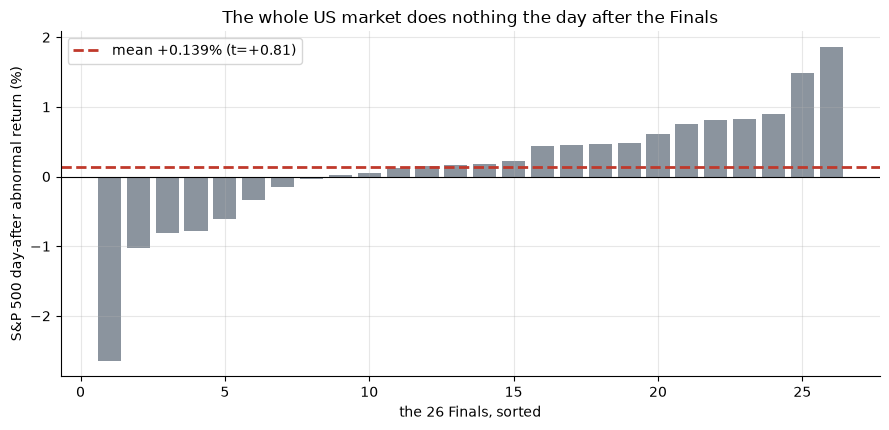

SPY day-after abnormal: mean +0.139%, t = +0.81


In [2]:
if HAVE_REAL:
    bm = st.broad_market_events(PRICES)
    s = st.one_sample_t(bm['abn'].values)
    spy_mean, spy_t = s['mean']*100, s['t']
    vals = bm['abn'].values*100
else:
    spy_mean, spy_t = R['spy_mean'], R['spy_t']
    rng = np.random.default_rng(734); vals = rng.normal(spy_mean, 0.9, 26)
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(range(1, len(vals)+1), sorted(vals), color=GREY)
ax.axhline(0, c='k', lw=.8)
ax.axhline(spy_mean, c=RED, lw=2, ls='--', label=f'mean {spy_mean:+.3f}% (t={spy_t:+.2f})')
ax.set_xlabel('the 26 Finals, sorted'); ax.set_ylabel('S&P 500 day-after abnormal return (%)')
ax.set_title('The whole US market does nothing the day after the Finals')
ax.legend(); plt.tight_layout(); plt.show()
print(f'SPY day-after abnormal: mean {spy_mean:+.3f}%, t = {spy_t:+.2f}')

The S&P 500 moves a statistically-invisible **+0.14%** the day after a Finals is decided. That's the whole problem in one chart: the World Cup effect works because Brazil's market and Germany's market are *different* markets, so one can fall while the other doesn't. But the Lakers and the Celtics both trade on the *same* US exchange — one city's elation and another's heartbreak land on the identical tape and **cancel out**. The only NBA Finals in 26 years that even spanned two countries was 2019 (Toronto over Golden State), and one event is not a test.

**But maybe the *city-level* proxy still catches something the broad market washes out? Let's look at the losing city.**

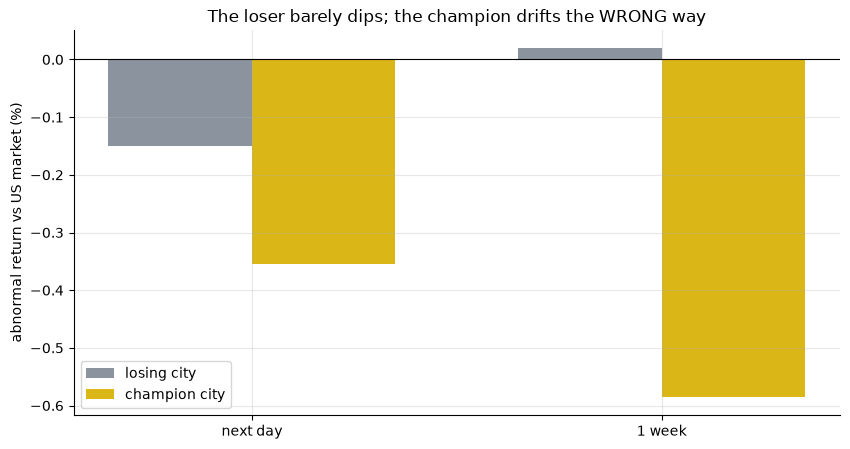

losing city  : next day -0.149 %  1 week 0.02 %
champion city: next day -0.354 %  1 week -0.586 %


In [3]:
if HAVE_REAL:
    ld = [st.one_sample_t(LOSER['ar_day'].values)['mean']*100,
          st.one_sample_t(LOSER['ar_week'].values)['mean']*100]
    cd = [st.one_sample_t(CHAMP['ar_day'].values)['mean']*100,
          st.one_sample_t(CHAMP['ar_week'].values)['mean']*100]
else:
    ld = [R['l_day_mean'], R['l_wk_mean']]; cd = [R['c_day_mean'], R['c_wk_mean']]
x = np.arange(2); width = 0.35
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.bar(x - width/2, ld, width, label='losing city', color=GREY)
ax.bar(x + width/2, cd, width, label='champion city', color=AMBER)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(['next day', '1 week'])
ax.set_ylabel('abnormal return vs US market (%)')
ax.set_title('The loser barely dips; the champion drifts the WRONG way')
ax.legend(); plt.tight_layout(); plt.show()
print('losing city  : next day', round(ld[0],3), '%  1 week', round(ld[1],3), '%')
print('champion city: next day', round(cd[0],3), '%  1 week', round(cd[1],3), '%')

The losing city's proxy dips a tiny **-0.15%** the next day — the right *direction* for the folklore, but so small it's indistinguishable from noise (*t* = -0.47), and it's **back to flat within a week** (+0.02%). The champion's city, which is supposed to *pop*, actually drifts **-0.35%** the wrong way. If civic joy moved markets, the amber bars should be up. They're down.

**Is that little loser-dip actually unusual, or just a normal week?** We redrew thousands of random (non-Finals) weeks on the same stocks and asked how often they dip at least as much:

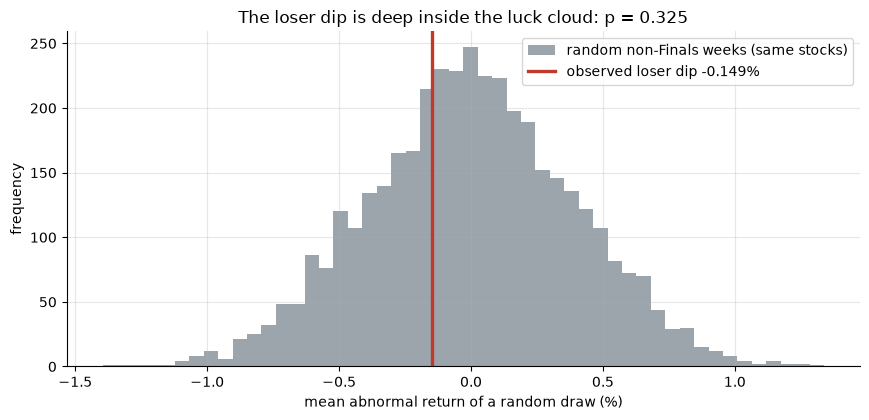

observed -0.149% vs placebo mean +0.015% -> p = 0.325


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV[EV['role']=='loser'], PRICES, 'ar_day', k=1,
                           entry_offset=0, tail='left', n_seeds=6, n_draws_per_seed=200)
    obs = pl['obs']*100; pm, ps = pl['placebo_mean']*100, pl['placebo_sd']*100
else:
    obs, pm, ps = R['l_day_mean'], R['pl_l_day_mean'], R['pl_l_day_sd']
rng = np.random.default_rng(734); draws = rng.normal(pm, ps, 4000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='random non-Finals weeks (same stocks)')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed loser dip {obs:+.3f}%')
ax.set_xlabel('mean abnormal return of a random draw (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The loser dip is deep inside the luck cloud: p = {R["pl_l_day_p"]:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {R['l_day_mean']:+.3f}% vs placebo mean {R['pl_l_day_mean']:+.3f}% "
      f"-> p = {R['pl_l_day_p']:.3f}")

A random week dips this much or more **about one time in three** (*p* = 0.325). The loser's "gloom" is smack in the middle of ordinary noise — not a signal.

**Finally, could you have traded any of it?** Buy or short the morning after, hold, pay costs:

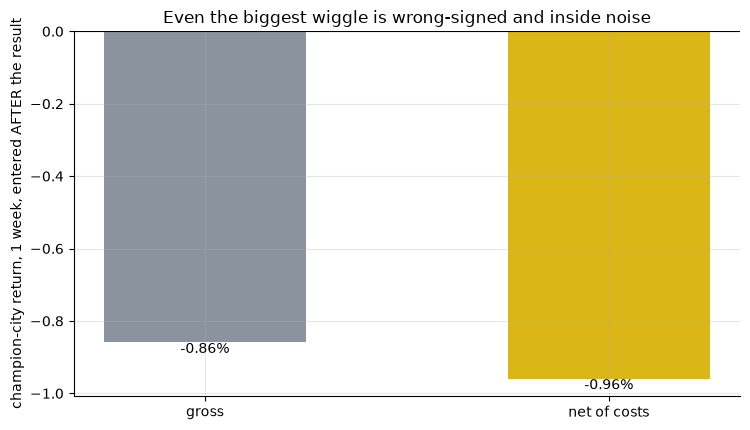

champion 1-week capture: gross -0.86%  net -0.96%


In [5]:
if HAVE_REAL:
    g = st.one_sample_t(CHAMP['cap_week_gross'].values)['mean']*100
    n5 = st.one_sample_t(CHAMP['cap_week_net'].values)['mean']*100
else:
    g, n5 = R['c_wk_cap_g'], R['c_wk_cap_n5']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['gross', 'net of costs'], [g, n5], color=[GREY, AMBER], width=.5)
for i, v in enumerate([g, n5]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('champion-city return, 1 week, entered AFTER the result')
ax.set_title('Even the biggest wiggle is wrong-signed and inside noise')
plt.tight_layout(); plt.show()
print(f'champion 1-week capture: gross {g:+.2f}%  net {n5:+.2f}%')

The one cut that comes closest to "significant" is the champion's city *under*performing over the following week (**-0.96%** net) — which is both the *opposite* of the feel-good story and, when we placebo-test it, just noise anyway (*p* = 0.12). There's nothing here to trade.

## 5 · The verdict

- **Signal — None.** The loser's dip is a coin-flip-sized whisper that reverts in days; the champion's pop points backwards; the broad market doesn't move at all. Nothing clears the desk's bar.
- **Tradability — Mirage.** No honest, costed, after-the-news trade works.
- **Does the loser's city dip? — Busted.** The mechanism is real for the World Cup, where countries have separate markets. The NBA Finals almost always pits two US cities against each other on one shared tape — so the mood cancels before it can move a price.

## 6 · Going further 🚪

- **This is a great lesson in *why* a real effect doesn't transfer.** The World Cup dip is real because Brazil and Germany are different markets. Copy the idea to a single country's domestic league and the very thing that made it work — cross-market variation — disappears. The mechanism didn't fail; the *setting* removed it.
- **The proxy is coarse, and we say so.** A single hometown stock is a noisy stand-in for a city's mood. A cleaner test would need a true metro-level index (which doesn't exist) or high-frequency local data around the final buzzer — the natural sequel.
- **Sibling studies:** the [Eurovision effect](../../708-eurovision-effect/) (the same event-study shape, but *across countries*, where the design has teeth), the [World Cup effect](../../235-world-cup-effect/) (the real Edmans mechanism), the [World Series effect](../../709-world-series-effect/) and the [Super Bowl indicator](../../158-super-bowl/) — every one a sports-mood folklore claim, tested the same honest way.

*Think the NBA Finals REALLY moves a city's market? Find a true metro index, or intraday local data around the buzzer, and show a net, replicated, placebo-surviving edge. We'll publish the teardown.*